Mounted at /content/drive
📥 Đang clone repository...
✅ Clone thành công!
📖 Đang đọc file JSONL...
Dòng 1: {"text": "the menu looked great, but the food was the biggest disappointment i've had yet!", "labels": [{"aspect": "menu", "polarity": "positive"}, {"aspect": "food", "polarity": "negative"}]}...
Dòng 2: {"text": "Pros : - Great sound for a $ 100 speaker at mid to higher levels .", "labels": [{"aspect": "sound", "polarity": "positive"}]}...
Dòng 3: {"text": "Service was friendly, but not terribly attentive, took 30 minutes after dinner to clear our plates, and another 20 to get our check.", "labels": [{"aspect": "Service", "polarity": "positive"...
📊 Tổng số câu gốc: 16127
📊 Số cặp (câu, aspect) sau xử lý: 30813
🔍 5 dòng đầu tiên:
                                                text   aspect sentiment
0  the menu looked great, but the food was the bi...     menu  positive
1  the menu looked great, but the food was the bi...     food  negative
2  Pros : - Great sound for a $ 100 spe

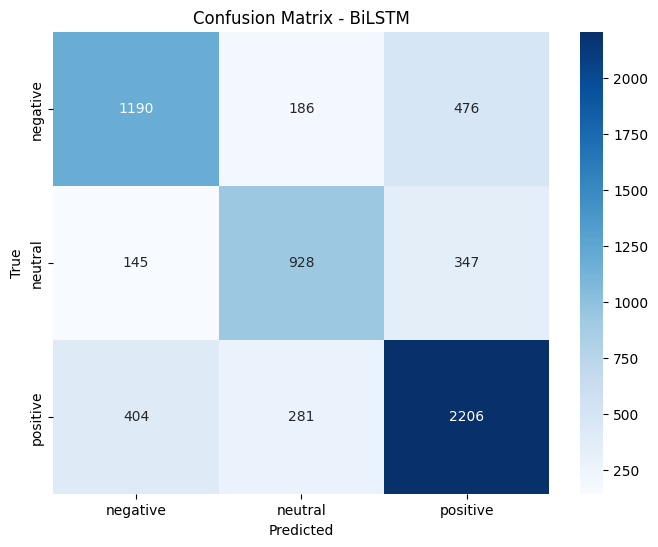


✅ Mô hình BiLSTM đã được lưu vào: /content/drive/MyDrive/bilstm_absa_model.pth

🔮 DỰ ĐOÁN MẪU:
'The screen is amazing but the battery is terrible.' | Aspect: screen -> positive
'The screen is amazing but the battery is terrible.' | Aspect: battery -> positive
'The food was delicious, but service was slow.' | Aspect: food -> positive
'The food was delicious, but service was slow.' | Aspect: service -> negative


In [ ]:
# ==================== 1. Kết nối Google Drive & cài thư viện ====================
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers torch pandas numpy scikit-learn matplotlib seaborn

import os
import json
import subprocess
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==================== 2. Tải dữ liệu từ GitHub ====================
repo_url = "https://github.com/ThanosDiam/ABSA-Analysis-with-Explainability-Methods.git"
repo_path = "ABSA-Analysis-with-Explainability-Methods"
dataset_file = "FINAL_CLEANED_CORRECTED_SHUFFLED_DATASET_NO_DUPLICATE.jsonl"

if not os.path.exists(repo_path):
    print("📥 Đang clone repository...")
    subprocess.run(["git", "clone", repo_url], check=True)
    print("✅ Clone thành công!")
else:
    print("✅ Repository đã có sẵn.")

file_path = os.path.join(repo_path, "Datasets", dataset_file)
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Không tìm thấy file {file_path}")

# ==================== 3. Đọc và phân tích cấu trúc dữ liệu ====================
print("📖 Đang đọc file JSONL...")
data = []
with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i < 3:
            print(f"Dòng {i+1}: {line.strip()[:200]}...")
        if line.strip():
            data.append(json.loads(line))

print(f"📊 Tổng số câu gốc: {len(data)}")

def extract_triplets(item):
    if 'text' in item and 'labels' in item:
        sent = item['text']
        for lbl in item['labels']:
            asp = lbl.get('aspect', '')
            pol = lbl.get('polarity', '')
            if asp and pol in ['positive','negative','neutral']:
                yield (sent, asp, pol)
    else:
        if 'sentence' in item and 'aspects' in item:
            sent = item['sentence']
            for asp in item['aspects']:
                term = asp.get('term', '')
                pol = asp.get('polarity', '')
                if term and pol in ['positive','negative','neutral']:
                    yield (sent, term, pol)

records = []
for item in data:
    for text, aspect, sentiment in extract_triplets(item):
        records.append({
            'text': text,
            'aspect': aspect,
            'sentiment': sentiment.lower().strip()
        })

df = pd.DataFrame(records)
print(f"📊 Số cặp (câu, aspect) sau xử lý: {len(df)}")
print("🔍 5 dòng đầu tiên:")
print(df.head())

label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

print("\n📈 Phân bố nhãn:")
print(df['sentiment'].value_counts())

# ==================== 4. Tiền xử lý cho BiLSTM ====================
df['input_str'] = df['text'] + " [SEP] " + df['aspect']

# Xây dựng từ điển (vocab) từ toàn bộ từ
all_words = []
for s in df['input_str']:
    all_words.extend(s.lower().split())
unique_words = sorted(set(all_words))
vocab = {word: idx+2 for idx, word in enumerate(unique_words)}
vocab['[PAD]'] = 0
vocab['[UNK]'] = 1
vocab_size = len(vocab)
print(f"📚 Kích thước từ điển: {vocab_size}")

def encode_sentence(s, max_len=128):
    words = s.lower().split()
    indices = [vocab.get(w, 1) for w in words[:max_len]]
    indices += [0] * (max_len - len(indices))
    return indices

class BiLSTMDataset(Dataset):
    def __init__(self, dataframe, max_len=128):
        self.texts = dataframe['input_str'].values
        self.labels = dataframe['label'].values
        self.max_len = max_len
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        enc = encode_sentence(self.texts[idx], self.max_len)
        return torch.tensor(enc, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
print(f"✅ Train size: {len(train_df)} | Test size: {len(test_df)}")

train_dataset = BiLSTMDataset(train_df)
test_dataset = BiLSTMDataset(test_df)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ==================== 5. Khởi tạo mô hình BiLSTM ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Sử dụng thiết bị: {device}")

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=2, num_classes=3, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True, dropout=dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(emb)
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.classifier(self.dropout(hidden_cat))

model = BiLSTM(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==================== 6. Huấn luyện (5 epochs) ====================
print("\n⏳ Bắt đầu huấn luyện (5 epochs)...")
for epoch in range(5):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/5 | Loss: {avg_loss:.4f}")

# ==================== 7. Đánh giá ====================
model.eval()
predictions, true_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

target_names = ['negative', 'neutral', 'positive']
print("\n📊 BÁO CÁO KẾT QUẢ TRÊN TẬP TEST:")
print(classification_report(true_labels, predictions, target_names=target_names))

cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - BiLSTM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ==================== 8. Lưu mô hình vào Google Drive ====================
save_path = "/content/drive/MyDrive/bilstm_absa_model"
torch.save(model.state_dict(), f"{save_path}.pth")
print(f"\n✅ Mô hình BiLSTM đã được lưu vào: {save_path}.pth")

# ==================== 9. Demo dự đoán ====================
def predict_sentiment(text, aspect):
    model.eval()
    input_str = f"{text} [SEP] {aspect}"
    enc = encode_sentence(input_str)
    input_tensor = torch.tensor(enc, dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()
    return target_names[pred]

print("\n🔮 DỰ ĐOÁN MẪU:")
examples = [
    ("The screen is amazing but the battery is terrible.", "screen"),
    ("The screen is amazing but the battery is terrible.", "battery"),
    ("The food was delicious, but service was slow.", "food"),
    ("The food was delicious, but service was slow.", "service"),
]
for text, asp in examples:
    res = predict_sentiment(text, asp)
    print(f"'{text}' | Aspect: {asp} -> {res}")

In [ ]:
import pandas as pd
import json

# Đọc file JSONL
file_jsonl = "/content/ABSA-Analysis-with-Explainability-Methods/Datasets/FINAL_CLEANED_CORRECTED_SHUFFLED_DATASET_NO_DUPLICATE.jsonl"

records = []
with open(file_jsonl, 'r') as f:
    for line in f:
        item = json.loads(line)
        text = item.get('text', '')
        for label in item.get('labels', []):
            aspect = label.get('aspect', '')
            polarity = label.get('polarity', '')
            records.append({'text': text, 'aspect': aspect, 'sentiment': polarity})

df = pd.DataFrame(records)
# Lưu thành CSV
df.to_csv('dataset_BiLSTM.csv', index=False, encoding='utf-8')

# Tải về máy
from google.colab import files
files.download('dataset_BiLSTM.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>